# Cross-Country Application

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src.demographics import bgp_growth_rate, simulate_cohort_sizes
from src.bgp import bgp_interest_rate
from src.olg import solve_transition

In [2]:
# Country TFR configurations (approximate historical values)
countries = {
    'Germany': dict(tfr_high=2.5, tfr_low=1.4, shock_year=1970, color='#2166ac'),
    'USA':     dict(tfr_high=2.5, tfr_low=1.8, shock_year=1970, color='#d6604d'),
    'Japan':   dict(tfr_high=2.0, tfr_low=1.4, shock_year=1975, color='#4dac26'),
    'China':   dict(tfr_high=3.0, tfr_low=1.6, shock_year=1980, color='#8856a7'),
}

# Shared structural parameters (same as Germany baseline)
base_params = dict(
    alpha=0.33, sigma=0.4, delta=0.05, beta=0.946,
    theta=2.0, gamma=0.015, J=80, chi=20, psi=60,
)
F_low, F_high = 20, 30

print(f"{'Country':<10}  {'tfr_high':>8}  {'tfr_low':>7}  {'shock':>6}")
print("-" * 40)
for name, cfg in countries.items():
    print(f"  {name:<8}  {cfg['tfr_high']:>8.1f}  {cfg['tfr_low']:>7.1f}  {cfg['shock_year']:>6d}")

Country     tfr_high  tfr_low   shock
----------------------------------------
  Germany        2.5      1.4    1970
  USA            2.5      1.8    1970
  Japan          2.0      1.4    1975
  China          3.0      1.6    1980


In [ ]:
results = {}

for name, cfg in countries.items():
    b_high = cfg['tfr_high'] / 20
    b_low  = cfg['tfr_low']  / 20
    shock  = cfg['shock_year']

    g_high = bgp_growth_rate(b_high, J=base_params['J'], F_low=F_low, F_high=F_high)
    g_low  = bgp_growth_rate(b_low,  J=base_params['J'], F_low=F_low, F_high=F_high)

    r_init     = bgp_interest_rate(g_high, b_high, **base_params)
    r_terminal = bgp_interest_rate(g_low,  b_low,  **base_params)

    dem = simulate_cohort_sizes(b_high, b_low, shock_year=shock,
                                 base_year=1900, end_year=2200,
                                 J=base_params['J'], F_low=F_low, F_high=F_high)

    res = solve_transition(
        dem['cohort_sizes'], dem['years'],
        r_init=r_init, r_terminal=r_terminal,
        phi=0.05, max_iter=2000, tol=1e-6,
        **base_params
    )

    r_path = res['r_path']
    yrs    = res['years']
    trough_idx = np.argmin(r_path)

    results[name] = dict(
        r_init=r_init, r_terminal=r_terminal,
        r_path=r_path, years=yrs,
        trough_r=r_path[trough_idx],
        trough_yr=int(yrs[trough_idx]),
        color=cfg['color'],
        shock_year=shock,
    )
    print(f"{name:<8}  r_init={r_init*100:.2f}%  r_term={r_terminal*100:.2f}%  "
          f"trough={r_path[trough_idx]*100:.2f}% ({int(yrs[trough_idx])})")

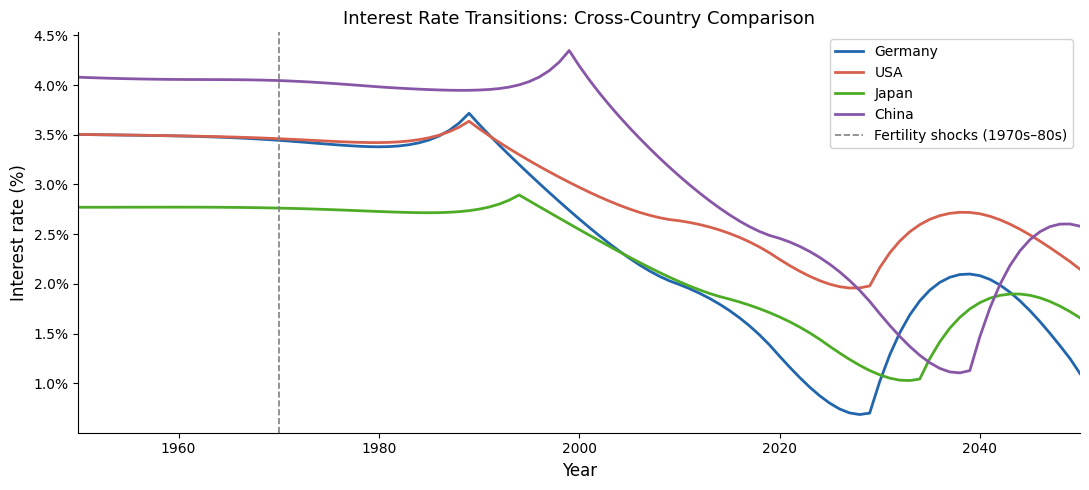

Saved figures/cross_country.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

for name, res in results.items():
    yrs   = res['years']
    mask  = (yrs >= 1950) & (yrs <= 2050)
    ax.plot(yrs[mask], res['r_path'][mask] * 100,
            color=res['color'], lw=2, label=name)

ax.axvline(1970, color='gray', lw=1.2, ls='--', label='Fertility shocks (1970s–80s)')
ax.set_xlim(1950, 2050)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Interest rate (%)', fontsize=12)
ax.set_title('Interest Rate Transitions: Cross-Country Comparison', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(loc='upper right', framealpha=0.9, fontsize=10)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig('../figures/cross_country.png', dpi=150)
plt.show()
print("Saved figures/cross_country.png")

## Cross-Country Differences

**Japan** reaches its trough earliest — the fertility shock hits in 1975 and its starting TFR (2.0) was already lower than Germany's, meaning the transition begins from a lower r_init with a smaller pre-shock cohort gap. **China**'s trough comes latest: the One Child Policy shock (1980) is 10 years delayed relative to Germany, and a higher pre-shock TFR (3.0) produces a sharper initial drop and a more severe terminal rate. **The USA** shows the shallowest decline — its post-shock TFR of 1.8 remains closer to replacement, generating a smaller demographic gap, a higher r_terminal, and the smallest overshoot of the four countries. All four paths share the same structural dynamics driven by the savings glut mechanism; the cross-country variation is entirely driven by the magnitude and timing of the fertility shock.